<div style="width:100%;height:125px;text-align:center;border: 4px solid #0590FD;background-color:#0590FD;color:white">

<header  style="width:100%;height:100px;">
  <h1><b> Face alignmentModels </b></h1>
    <h4> Testing 14 </h4>
</header>

<div> 

<div style="border: 4px solid #0590FD;background-color:#BFE6FF;color:black;border-radius: 5px;padding:7px;box-shadow: 0 1px 1px 0 #00264D, 0 6px 20px 0 rgba(1, 1, 1, 1)">
<div style="box-shadow: 0 1px 8px 0 #00264D, 0 6px 20px 0 rgba(0, 0, 0, 0.19);padding:0.5%;margin:6px;border-radius: 25px;width:10%;text-align:center">    
  <strong> Refrence: </strong><br></div>  
<div style="box-shadow: 0 1px 12px 0 #00264D, 0 6px 20px 0 rgba(0, 0, 0, 0.19);padding:1%;margin:6px;border-radius: 25px;margin-top:8px"> 
    
1. 
    
    
</div>    
</div>

<div style="border: 4px solid #0590FD;background-color:white;color:black;border-radius: 5px;padding:7px;box-shadow: 0 1px 1px 0 #00264D, 0 6px 20px 0 rgba(1, 1, 1, 1)">
    <div style="box-shadow: 0 1px 8px 0 #00264D, 0 6px 20px 0 rgba(0, 0, 0, 0.19);padding:0.5%;margin:6px;border-radius: 25px;width:10%;text-align:center">   
    <strong> Summary: </strong><br></div>  
<div style="box-shadow: 0 1px 12px 0 #00264D, 0 6px 20px 0 rgba(0, 0, 0, 0.19);padding:1%;margin:6px;border-radius: 25px;margin-top:8px">  


    
</div>
</div>

<div id="1" style="width:100%;height:atuo;border: 4px solid #0590FD;background-color:#0590FD;color:white;text-align:center;border-radius: 25px;padding:3px">
<div style="box-shadow: 0 1px 4px 0 #00264D, 0 60px 20px 0 rgba(1, 1, 1, 1);padding:0.5%;margin:6px;border-radius: 25px"> 
           
<h4><b> Face alignment by PRnet (old model) </b></h4>
</div></div>

<div id="1" style="width:100%;height:atuo;border: 1px solid #0590FD;background-color:#0590FD;color:white;text-align:center;border-radius: 15px;padding:3px">
    
<h4>  </h4>
</div>

In [ ]:
def face_alignment(image):
    '''
    Let's find and angle of the face. First calculate 
    the center of left and right eye by using eye landmarks.
    '''
    max_size = max(image.shape[0], image.shape[1])
    if max_size> 1000:
        image = rescale(image, 1000./max_size)
        image = (image*255).astype(np.uint8)
    pos = prn.process(image) # use dlib to detect face   
    kpt = prn.get_landmarks(pos)
    
    first,  second, third = [],[],[]
    for ith,_ in enumerate(kpt):
        for jth, value in enumerate(kpt[ith]):
            if jth == 0:
                first.append(value)
            if jth == 1:
                second.append(value)
            if jth == 2:
                third.append(value)       
    
    #y_max, y_min = int(max(second)), int(min(second))
    #x_max, x_min = int(max(first)), int(min(first))
    #desiredWidth =   y_min - y_max +100
    #desiredHeight =  x_min - x_max +100
    #print(desiredWidth, desiredHeight)
    desiredWidth, desiredHeight = 1200, 1200
    
    leftEyePts = [[],[]]
    rightEyePts = [[],[]]
    leftEyePts[0], leftEyePts[1] =  first[36:42], second[36:42]
    rightEyePts[0], rightEyePts[1] =  first[42:48], second[42:48]
    
    leftEyeCenter = [[],[]]
    rightEyeCenter = [[],[]]
    
    leftEyeCenter[0] = np.array(leftEyePts[0]).mean(axis=0).astype("int")
    leftEyeCenter[1] =  np.array(leftEyePts[1]).mean(axis=0).astype("int")
    
    rightEyeCenter[0] = np.array(rightEyePts[0]).mean(axis=0).astype("int")
    rightEyeCenter[1] =  np.array(rightEyePts[1]).mean(axis=0).astype("int")

    
    leftEyeCenter = (leftEyeCenter[0],leftEyeCenter[1])
    rightEyeCenter = (rightEyeCenter[0],rightEyeCenter[1])
    

    
    # find and angle of line by using slop of the line.
    dY = rightEyeCenter[1] - leftEyeCenter[1]
    dX = rightEyeCenter[0] - leftEyeCenter[0]
    angle = np.degrees(np.arctan2(dY, dX)) - 0.27
    
    # to get the face at the center of the image,
    # set desired left eye location. Right eye location 
    # will be found out by using left eye location.
    # this location is in percentage.
    desiredLeftEye=(0.35, 0.35)
    #Set the croped image(face) size after rotaion.
   
    desiredFaceWidth , desiredFaceHeight = desiredWidth, desiredHeight

    desiredRightEyeX = 1.0 - desiredLeftEye[0]
    
    # determine the scale of the new resulting image by taking
    # the ratio of the distance between eyes in the *current*
    # image to the ratio of distance between eyes in the
    # *desired* image
    dist = np.sqrt((dX ** 2) + (dY ** 2))
    desiredDist = (desiredRightEyeX - desiredLeftEye[0])
    desiredDist *= desiredFaceWidth
    scale = desiredDist / dist
    # compute center (x, y)-coordinates (i.e., the median point)
    # between the two eyes in the input image
    eyesCenter = ((leftEyeCenter[0] + rightEyeCenter[0]) // 2,
                        (leftEyeCenter[1] + rightEyeCenter[1]) // 2)
    
    
    # grab the rotation matrix for rotating and scaling the face
    M = cv2.getRotationMatrix2D(eyesCenter, angle, scale)

    # update the translation component of the matrix
    tX = desiredFaceWidth * 0.5
    tY = desiredFaceHeight * desiredLeftEye[1]
    M[0, 2] += (tX - eyesCenter[0])
    M[1, 2] += (tY - eyesCenter[1])

    # apply the affine transformation
    (w, h) = (desiredFaceWidth, desiredFaceHeight)
    #(y2,x2,y1,x1) = face_locations[0] 
        
    output = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC)
    return output #output leftEyeCenter ,rightEyeCenter 

<div id="1" style="width:100%;height:atuo;border: 4px solid #0590FD;background-color:#0590FD;color:white;text-align:center;border-radius: 25px;padding:3px">
<div style="box-shadow: 0 1px 4px 0 #00264D, 0 60px 20px 0 rgba(1, 1, 1, 1);padding:0.5%;margin:6px;border-radius: 25px"> 
           
<h4><b> Face alignment by Moblienet landmark </b></h4>
</div></div>

<div style="border: 4px solid #0590FD;background-color:#BFE6FF;color:black;border-radius: 5px;padding:7px;box-shadow: 0 1px 1px 0 #00264D, 0 6px 20px 0 rgba(1, 1, 1, 1)">
<div style="box-shadow: 0 1px 8px 0 #00264D, 0 6px 20px 0 rgba(0, 0, 0, 0.19);padding:0.5%;margin:6px;border-radius: 25px;width:10%;text-align:center">    
  <strong> Refrence: </strong><br></div>  
<div style="box-shadow: 0 1px 12px 0 #00264D, 0 6px 20px 0 rgba(0, 0, 0, 0.19);padding:1%;margin:6px;border-radius: 25px;margin-top:8px"> 
    
1. https://www.youtube.com/watch?v=SLLZr9IjPcE
2. https://pypi.org/project/face-alignment/
3. https://www.pyimagesearch.com/2017/05/22/face-alignment-with-opencv-and-python/
    
    
</div>    
</div>

<div style="border: 4px solid #0590FD;background-color:white;color:black;border-radius: 5px;padding:7px;box-shadow: 0 1px 1px 0 #00264D, 0 6px 20px 0 rgba(1, 1, 1, 1)">
    <div style="box-shadow: 0 1px 8px 0 #00264D, 0 6px 20px 0 rgba(0, 0, 0, 0.19);padding:0.5%;margin:6px;border-radius: 25px;width:10%;text-align:center">   
    <strong> theory: </strong><br></div>  
<div style="box-shadow: 0 1px 12px 0 #00264D, 0 6px 20px 0 rgba(0, 0, 0, 0.19);padding:1%;margin:6px;border-radius: 25px;margin-top:8px">  
 

    
</div>
</div>

## Keywords:
1. Mean shape

2. VGG-face
3. Google face
4. OpenFace
5. Facebook DeepFace
6. 

### **Points inforamtion:**
```
array([[[0.33677918, 0.31765747], # eyes_left
        [0.35409307, 0.5485608 ], # eyes_right
        [0.45027667, 0.3924486 ], # noise
        [0.5295859 , 0.3064919 ], # mouth_left
        [0.54217046, 0.5102326 ]]], # mouth_right
        dtype=float32)



```

In [1]:
import cv2
from FarhadCV.Tools import read_files, read_folders, estimater, tcolors
from FaceDecMobilenets import SSDFaceDetector, LandmarkDetector

import numpy as np
import matplotlib.pyplot as plt

In [7]:
class FaceAlignment():
    def __init__(self, model_direction = "./MobilenetModels/mobilenet_fp32_cpu.tflite"):
        
        self.LD =  LandmarkDetector(model_direction)
        
    def fit(self, image, angle = 0):
        
        height, width, _ = image.shape 
        self.angle = angle
        landmarksold = self.LD.predict(image)
        #find center of the face
        landmarks = [[]]
        for ith, land in enumerate(landmarksold[0]):
            landmarks[0].append([])
            landmarks[0][ith].append(land[1] * height)
            landmarks[0][ith].append(land[0] * width)
        center_of_face = landmarks[0][2]
        center_distance = np.sqrt((width/2 - center_of_face[0])**2 + (height/2 - center_of_face[1])**2)
        
        l_dist = height *  width
    
        if(l_dist > center_distance):
            l_dist = center_distance       
    
    
        face_scale=1.1
        face_dim = self.find_face_dim(landmarks, height, width) * face_scale
        
        ew_bounding_box=[center_of_face[0]-face_dim/2,center_of_face[1]-face_dim/2, face_dim, face_dim]
    
        #get rotation angle
        if self.angle == 0:
            scale=0.7
        else:
            scale=1.2
        trotate = self.get_rotation_matrix(landmarks, center_of_face, image, scale)
        warped = cv2.warpAffine(image, trotate, (width, height))
        
        
        return warped, self.average_angle
        
    def find_face_dim(self, landmarks, heigth, width):
        #find dimention of face in pixels as average of width and height
    
        xList = []
        yList = []
        for x,y in landmarks[0]:
            yList.append(y)
            xList.append(x)
    
    
        #y_max, y_min = int(np.max(yList) * heigth), int(np.min(yList) * heigth)
        #x_max, x_min = int(np.max(xList) * width) , int(np.min(xList) * width)
    
        y_max, y_min = int(np.max(yList) * heigth), int(np.min(yList) * heigth)
        x_max, x_min = int(np.max(xList) * width) , int(np.min(xList) * width)
    
    
    
    
    
        croped_points = (y_min,y_max, x_min,x_max)
    
        #dim = ((y_max - y_min) + (x_max - x_min))/2
        dim = ((y_max - y_min) + (x_max - x_min) +1200)
        return dim
    def get_rotation_matrix(self, landmarks, rotation_point, face_img, scale):
        # get rotation matrix as average angle between eyes points and mouse corner points
        #face points
        if self.angle == 0:
            left_eye_pt = landmarks[0][0]
            right_eye_pt = landmarks[0][1]
            left_mouth_pt = landmarks[0][3]
            right_mouth_pt =landmarks[0][4]
            #angles
            eye_angle = self.angle_between_2_pt(left_eye_pt, right_eye_pt)
            mouth_angle  = self.angle_between_2_pt(left_mouth_pt, right_mouth_pt)
            self.average_angle = (eye_angle + mouth_angle)/2 
        else:
            self.average_angle =  - self.angle
        
        
        
        #rotation
        M = cv2.getRotationMatrix2D((rotation_point[0], rotation_point[1]), self.average_angle, scale )
        return M
    def angle_between_2_pt(self,p1, p2):
        # to calculate the angle rad by two points   
        x1, y1 = p1
        x2, y2 = p2
        tan_angle = (y2 - y1) / (x2 - x1)
        return (np.degrees(np.arctan(tan_angle)))

In [1]:
!touch 001_decoderFormat.txt

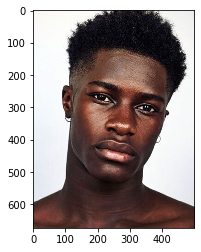

In [245]:
#IMAGE_DIR =  "/Users/farhad/Pictures/Scarlett_Johansson/Good/Scarlett_Johansson_2.jpg"
IMAGE_DIR =  "/Users/farhad/Pictures/SpetemberImages/12a7c5e530ea41ec94dcd7a1e29ab6dd.jpg"
image = cv2.imread(IMAGE_DIR)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()

In [246]:
model_direction = "./MobilenetModels/mobilenet_fp32_cpu.tflite"

SAli = FaceAlignment(model_direction)
output1, angle1 = SAli.fit(image, angle = 0)

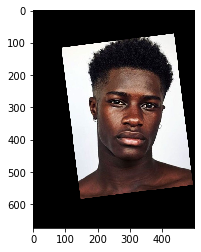

In [247]:
plt.imshow(output1)
plt.show()

In [248]:
output2, angle2 = SAli.fit(output1, angle = angle1)

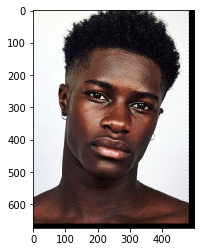

In [249]:
plt.imshow(output2)
plt.show()

<div id="1" style="width:100%;height:atuo;border: 4px solid #0590FD;background-color:#0590FD;color:white;text-align:center;border-radius: 25px;padding:3px">
<div style="box-shadow: 0 1px 4px 0 #00264D, 0 60px 20px 0 rgba(1, 1, 1, 1);padding:0.5%;margin:6px;border-radius: 25px"> 
           
<h4><b> Face alignment and face croped and encoded face and pyt in first place </b></h4>
</div></div>

In [ ]:
import cv2
from FarhadCV.Tools import read_files, read_folders, estimater, tcolors
from FaceDecMobilenets import SSDFaceDetector, LandmarkDetector

import numpy as np
import matplotlib.pyplot as plt

In [20]:
class FaceAlignment():
    def __init__(self, model_direction = "./MobilenetModels/mobilenet_fp32_cpu.tflite"):
        
        self.LD =  LandmarkDetector(model_direction)
        
    def fit(self, image, angle = 0):
        
        height, width, _ = image.shape 
        self.angle = angle
        landmarksold = self.LD.predict(image)
        #find center of the face
        landmarks = [[]]
        for ith, land in enumerate(landmarksold[0]):
            landmarks[0].append([])
            landmarks[0][ith].append(land[1] * height)
            landmarks[0][ith].append(land[0] * width)
        center_of_face = landmarks[0][2]
        center_distance = np.sqrt((width/2 - center_of_face[0])**2 + (height/2 - center_of_face[1])**2)
        
        l_dist = height *  width
    
        if(l_dist > center_distance):
            l_dist = center_distance       
    
    
        face_scale=1.1
        face_dim = self.find_face_dim(landmarks, height, width) * face_scale
        
        ew_bounding_box=[center_of_face[0]-face_dim/2,center_of_face[1]-face_dim/2, face_dim, face_dim]
    
        #get rotation angle
        if self.angle == 0:
            scale=1
        else:
            scale=1
        trotate = self.get_rotation_matrix(landmarks, center_of_face, image, scale)
        warped = cv2.warpAffine(image, trotate, (width, height))
        
        
        return warped, self.average_angle
        
    def find_face_dim(self, landmarks, heigth, width):
        #find dimention of face in pixels as average of width and height
    
        xList = []
        yList = []
        for x,y in landmarks[0]:
            yList.append(y)
            xList.append(x)
    
    
        #y_max, y_min = int(np.max(yList) * heigth), int(np.min(yList) * heigth)
        #x_max, x_min = int(np.max(xList) * width) , int(np.min(xList) * width)
    
        y_max, y_min = int(np.max(yList) * heigth), int(np.min(yList) * heigth)
        x_max, x_min = int(np.max(xList) * width) , int(np.min(xList) * width)
    
    
    
    
    
        croped_points = (y_min,y_max, x_min,x_max)
    
        #dim = ((y_max - y_min) + (x_max - x_min))/2
        dim = ((y_max - y_min) + (x_max - x_min) +1200)
        return dim
    def get_rotation_matrix(self, landmarks, rotation_point, face_img, scale):
        # get rotation matrix as average angle between eyes points and mouse corner points
        #face points
        if self.angle == 0:
            left_eye_pt = landmarks[0][0]
            right_eye_pt = landmarks[0][1]
            left_mouth_pt = landmarks[0][3]
            right_mouth_pt =landmarks[0][4]
            #angles
            eye_angle = self.angle_between_2_pt(left_eye_pt, right_eye_pt)
            mouth_angle  = self.angle_between_2_pt(left_mouth_pt, right_mouth_pt)
            self.average_angle = (eye_angle + mouth_angle)/2 
        else:
            self.average_angle =  - self.angle
        
        
        
        #rotation
        M = cv2.getRotationMatrix2D((rotation_point[0], rotation_point[1]), self.average_angle, scale )
        return M
    def angle_between_2_pt(self,p1, p2):
        # to calculate the angle rad by two points   
        x1, y1 = p1
        x2, y2 = p2
        tan_angle = (y2 - y1) / (x2 - x1)
        return (np.degrees(np.arctan(tan_angle)))

<div id="1" style="width:100%;height:atuo;border: 1px solid #0590FD;background-color:#0590FD;color:white;text-align:center;border-radius: 15px;padding:3px">
    
<h4> Encoder </h4>
</div>

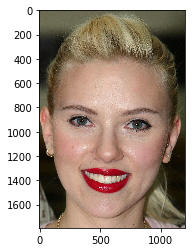

In [41]:
IMAGE_DIR =  "/Users/farhad/Pictures/Scarlett_Johansson/Good/Scarlett_Johansson_2.jpg"
#IMAGE_DIR =  "/Users/farhad/Pictures/SpetemberImages/12a7c5e530ea41ec94dcd7a1e29ab6dd.jpg"
image = cv2.imread(IMAGE_DIR)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()

In [32]:
model_direction = "./MobilenetModels/mobilenet_fp32_cpu.tflite"

SAli = FaceAlignment(model_direction)
output1, angle1 = SAli.fit(image, angle = 0)

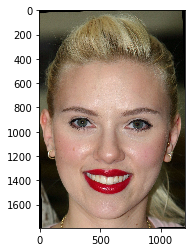

In [33]:
plt.imshow(output1);plt.show()

[[[0.07978612 0.1653785 ]
  [0.98927718 0.8827098 ]]]


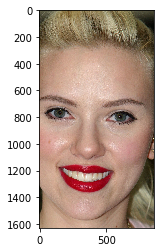

In [42]:
import FaceDetectionModels as FD
faceModel_dir = "./MobilenetModels/ssd_int8_cpu.tflite"
face, points = FD.Mobilenetboxes(output1, faceModel_dir)

plt.imshow(face);plt.show()

INFO:tensorflow:Saver not created because there are no variables in the graph to restore
INFO:tensorflow:The specified SavedModel has no variables; no checkpoints were restored.


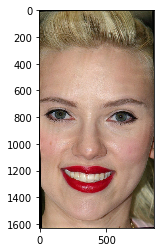

In [44]:
from FSSEncoderModels import FSSEncoder

model_path = "/Users/farhad/Documents/VisaTeam/VisaProgramming01/New_Models/INCM_bits100_border_image_x03"
encoder = FSSEncoder(model_path)
encoder.BCH_Generator("VisTe")
encoder.fitOneShot(face)


plt.imshow(encoder.encoded_face);plt.show()

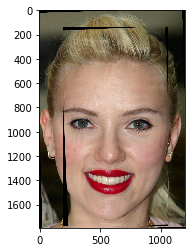

In [46]:
y_min,y_max, x_min,x_max = points
encoded_image = image.copy()
encoded_image[y_min:y_max, x_min:x_max] = encoder.encoded_face
encoded_image = encoded_image.copy()

plt.imshow(encoded_image);plt.show()

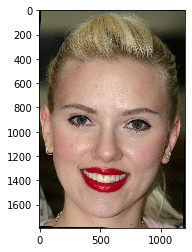

In [47]:
output2, _ = SAli.fit(encoded_image, angle = angle1)
plt.imshow(output2);plt.show()

<div id="1" style="width:100%;height:atuo;border: 1px solid #0590FD;background-color:#0590FD;color:white;text-align:center;border-radius: 15px;padding:3px">
    
<h4>  Decoder </h4>
</div>

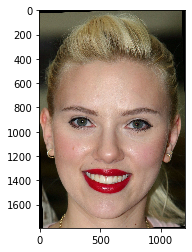

In [48]:
model_direction = "./MobilenetModels/mobilenet_fp32_cpu.tflite"

SAli = FaceAlignment(model_direction)
output3, _ = SAli.fit(output2, angle = 0)
plt.imshow(output3);plt.show()

[[[0.08952355 0.17455639]
  [0.97953975 0.89188769]]]


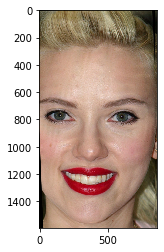

In [54]:
import FaceDetectionModels as FD
faceModel_dir = "./MobilenetModels/ssd_int8_cpu.tflite"
face2, points = FD.Mobilenetboxes(encoded_image, faceModel_dir)
plt.imshow(face2);plt.show()

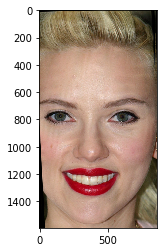

In [55]:
model_direction = "./MobilenetModels/mobilenet_fp32_cpu.tflite"

SAli = FaceAlignment(model_direction)
face2, _ = SAli.fit(face2, angle = 0)
plt.imshow(face2);plt.show()

In [56]:
from FSSDecoderModels import FSSDecoder

model_path = "/Users/farhad/Documents/VisaTeam/VisaProgramming01/New_Models/INCM_bits100_border_image_x03"
decoder = FSSDecoder(model_path)
decoder.fitOneShot(face2)
decoder.BCH_Reader()

print(decoder.decoded_msg)

INFO:tensorflow:Saver not created because there are no variables in the graph to restore
INFO:tensorflow:The specified SavedModel has no variables; no checkpoints were restored.
 
 message: VisTe 
VisTe


<div id="1" style="width:100%;height:atuo;border: 4px solid #0590FD;background-color:#0590FD;color:white;text-align:center;border-radius: 25px;padding:3px">
<div style="box-shadow: 0 1px 4px 0 #00264D, 0 60px 20px 0 rgba(1, 1, 1, 1);padding:0.5%;margin:6px;border-radius: 25px"> 
           
<h4><b> Face alignment and face croped and encoded face and pyt in first place </b></h4>
</div></div>

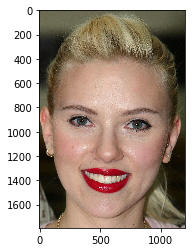

In [75]:
IMAGE_DIR =  "/Users/farhad/Pictures/Scarlett_Johansson/Good/Scarlett_Johansson_2.jpg"
#IMAGE_DIR =  "/Users/farhad/Pictures/SpetemberImages/12a7c5e530ea41ec94dcd7a1e29ab6dd.jpg"
image = cv2.imread(IMAGE_DIR)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()

In [76]:
import FaceDetectionModels as FD
faceModel_dir = "./MobilenetModels/ssd_int8_cpu.tflite"
_, points = FD.Mobilenetboxes(image, faceModel_dir)

#plt.imshow(face);plt.show()

[[[0.07978612 0.1653785 ]
  [0.98927718 0.8827098 ]]]


In [78]:
model_direction = "./MobilenetModels/mobilenet_fp32_cpu.tflite"

SAli = FaceAlignment(model_direction)
image, angle1 = SAli.fit(image, angle = 0)

face, _ = FD.Mobilenetboxes(image, faceModel_dir)

[[[0.09640288 0.17018208]
  [0.98662841 0.88395522]]]


INFO:tensorflow:Saver not created because there are no variables in the graph to restore
INFO:tensorflow:The specified SavedModel has no variables; no checkpoints were restored.


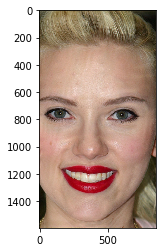

In [79]:
from FSSEncoderModels import FSSEncoder

model_path = "/Users/farhad/Documents/VisaTeam/VisaProgramming01/New_Models/INCM_bits100_border_image_x03"
encoder = FSSEncoder(model_path)
encoder.BCH_Generator("VisTe")
encoder.fitOneShot(face)


plt.imshow(encoder.encoded_face);plt.show()

In [80]:
encoded_face2, _ = SAli.fit(encoder.encoded_face, angle = angle1)

In [81]:
y_min,y_max, x_min,x_max = points
encoded_image = image.copy()
encoded_image[y_min:y_max, x_min:x_max] = encoded_face2
encoded_image = encoded_image.copy()

plt.imshow(encoded_image);plt.show()

ValueError: could not broadcast input array from shape (1596,856,3) into shape (1630,861,3)

In [ ]:
output2, _ = SAli.fit(image, angle = angle1)
plt.imshow(output2);plt.show()